This notebook contains some exploration of the NNMF templates for the DESI Dwarf catalog

In [161]:
import numpy as np
import matplotlib.pyplot as plt
# Define normalization
import os
import random
import argparse
from astropy.table import Table, vstack
import h5py
import matplotlib as mpl
import sys

%load_ext autoreload
%autoreload 2

    
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [162]:
from desi_lowz_funcs import make_subplots

In [163]:
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# load the MAIN extension directly as an Astropy Table
data_cat = Table.read(filename, hdu="MAIN")


In [164]:
h5_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/desi_dr1_dwarf_catalog_nnmf_pca.h5"
with h5py.File(h5_path, "r") as f:
    pca_coeffs = f["PCA_COEFFS"][:]       # shape (N, 20)
    nnmf_coeffs = f["NNMF_COEFFS"][:]     # shape (N, 10)
    tgids = f["TARGETID"][:]
    norm_facs = f["NORM_FACTOR"][:]
    flux_norm = f["FLUX_NORM"][:]
    wave_rest = f["WAVE_REST"][:]
    
    

In [141]:
## load the nnmf templates !
nnmf_temps = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/nnmf_templates/templates_dwarfs_v2.npy")
print(nnmf_temps.shape)



(3980, 10)


In [142]:
pca_temps = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/pca_components.npy")
print(pca_temps.shape)


(20, 3980)


In [67]:
import seaborn as sns
import colorcet as cc


palette_1 = cc.glasbey_light[:10]  # bright, distinct
palette_2 = cc.glasbey[:10]  # bright, distinct
palette_3 = sns.color_palette("Paired", 10)
palette_4 = sns.color_palette("colorblind", 10)


In [196]:
# pick a pretty palette

def plot_nnmf_templates(wave_rest, nnmf_temps, pca_temps, palette, palette_pca):

    fig, ax = plt.subplots(2, 2, figsize=(20, 10))
    plt.subplots_adjust(wspace=0.1)
    
    lw = 1
    left_inds  = [0, 1, 5, 8, 9]
    right_inds = [2, 3, 4, 6, 7]
    
    for i in left_inds:
        ax[0,0].plot(
            wave_rest,
            nnmf_temps[:, i],
            lw=lw,
            color=palette[i],
            label=f"NNMF {i+1}"
        )
    
    for i in right_inds:
        ax[0,1].plot(
            wave_rest,
            nnmf_temps[:, i],
            lw=lw,
            color=palette[i],
            label=f"NNMF {i+1}"
        )
    
    leg0 = ax[0,0].legend(frameon=False, fontsize=14,loc="lower right",ncol=3)
    leg1 = ax[0,1].legend(frameon=False, fontsize=14,loc="upper right",ncol=1)

    for leg in (leg0, leg1):
        for line in leg.legend_handles:
            line.set_linewidth(4.0)   # choose thickness you like
    
    ax[0,0].set_xlim(3600, 9000)
    ax[0,1].set_xlim(3600, 9000)
    
    ax[0,0].set_ylim([0,2.1])
    ax[0,1].set_ylim([0,10])



    ###PLOT PCA NOW

    for i in range(5):
        ax[1,0].plot(
            wave_rest,
            pca_temps[i],
            lw=lw,
            color=palette_pca[i+5],
            label=f"PCA {i+1}",
            zorder = 5-i
        )
    
    for i in range(5,10):
        ax[1,1].plot(
            wave_rest,
            pca_temps[i],
            lw=lw,
            color=palette_pca[i-5],
            label=f"PCA {i+1}",
            zorder = 10-i
        )


    ax[1,0].set_xlim(3600, 9000)
    ax[1,1].set_xlim(3600, 9000)
    
    ax[1,0].set_ylim([-0.1,0.1])
    ax[1,1].set_ylim([-0.1,0.1])

    leg0 = ax[1,0].legend(frameon=False, fontsize=14,loc="lower right",ncol=2)
    leg1 = ax[1,1].legend(frameon=False, fontsize=14,loc="upper right",ncol=2)

    for leg in (leg0, leg1):
        for line in leg.legend_handles:
            line.set_linewidth(4.0)   # choose thickness you like

    ax[1,0].set_yticks([-0.1,0,0.1])
    ax[1,1].set_yticks([-0.1,0,0.1])

    ax[1,0].set_xlabel(r"Rest-frame Wavelength ($\AA$)",fontsize =17)
    ax[1,1].set_xlabel(r"Rest-frame Wavelength ($\AA$)",fontsize =17)

    for axi in ax:
        for axii in axi:
            axii.tick_params(axis='both', which='major', labelsize=17)  # major ticks
    
    plt.savefig("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/plots/nnmf_pca_templates.pdf", bbox_inches="tight")
    
    plt.show()
        
    return



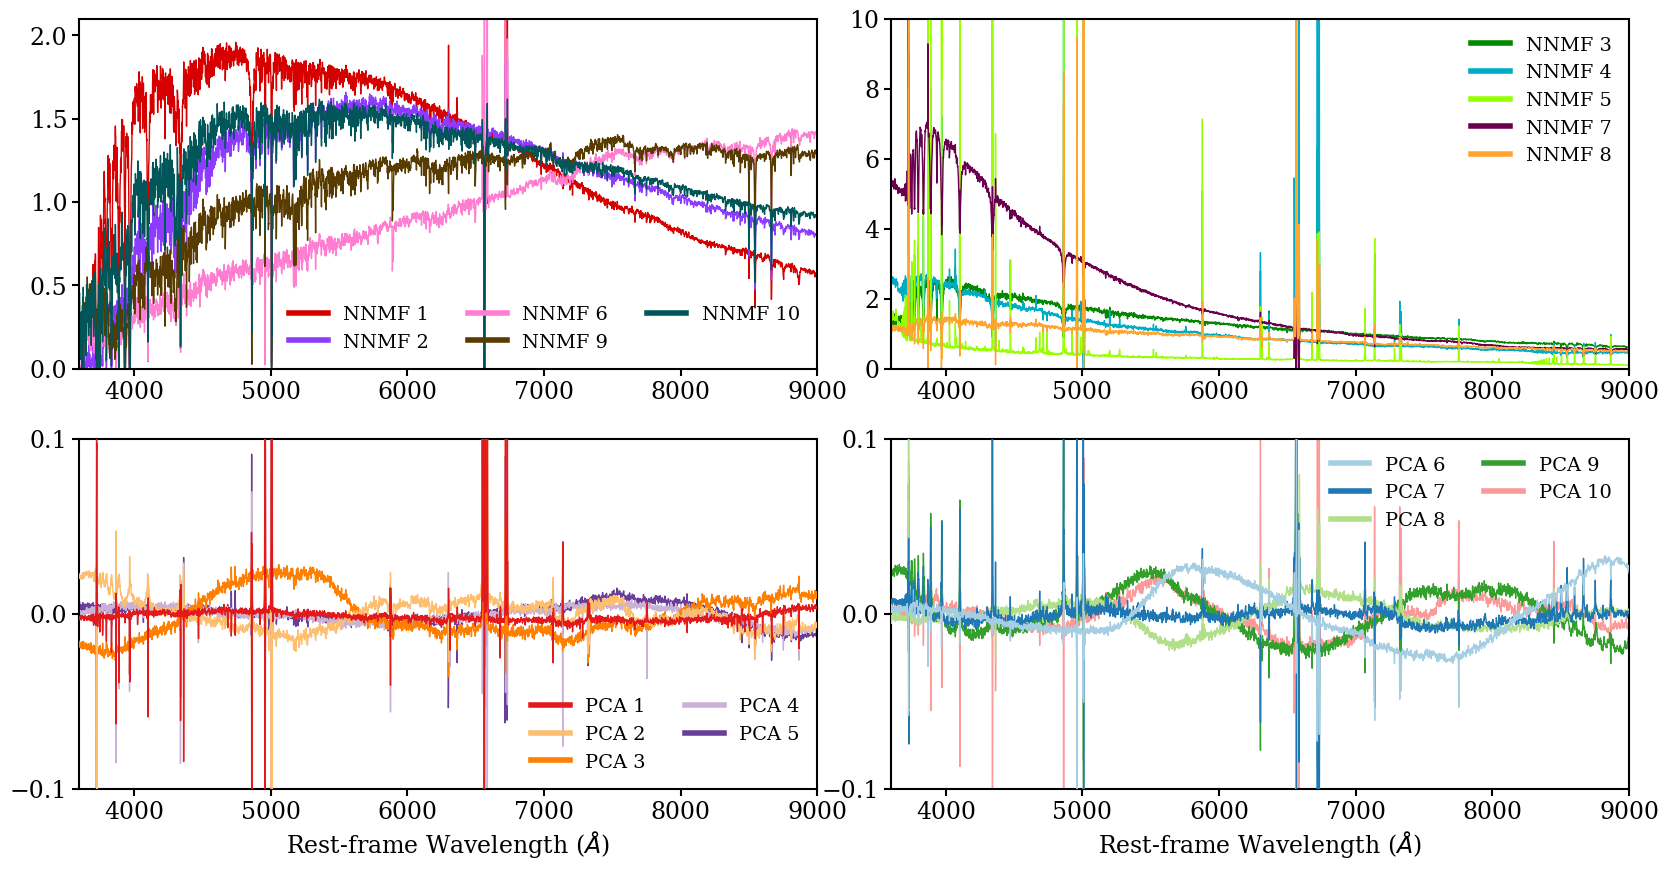

In [197]:
plot_nnmf_templates(wave_rest, nnmf_temps, pca_temps, palette_2, palette_3 )


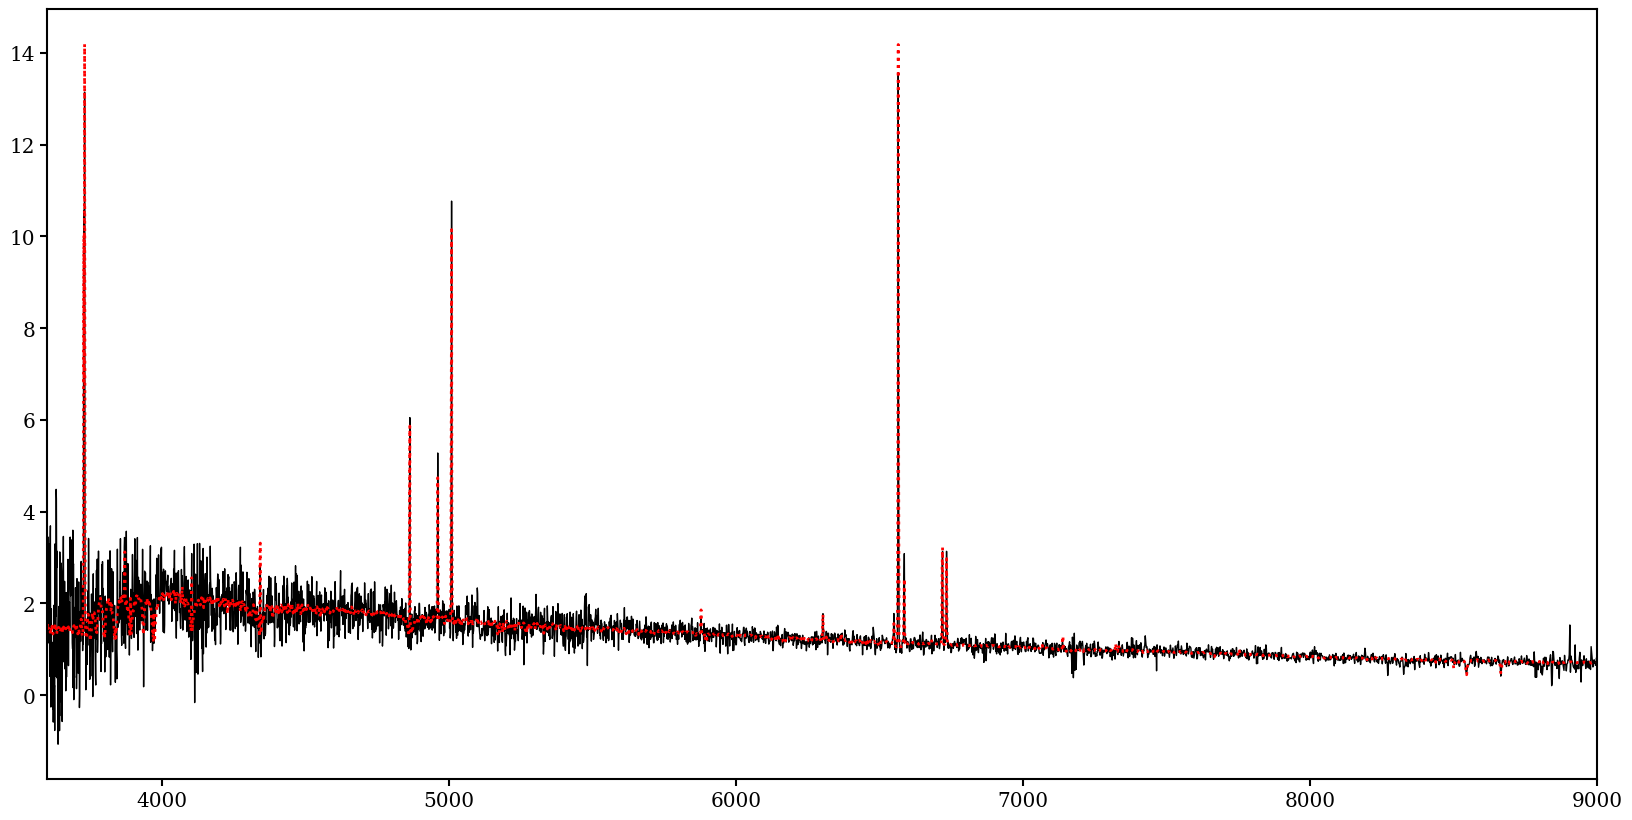

In [101]:
plt.figure(figsize = (20,10))
plt.plot(wave_rest, flux_norm[:,5],lw=1,color="k")

nnmf_fit = get_nnmf_fit( nnmf_coeffs[5], nnmf_temps ) 

plt.plot(wave_rest,nnmf_fit,lw=2,alpha=1,color = "r",ls="dotted")

plt.xlim([3600,9000])
plt.show()

In [246]:
def nnmf_resid_plot(nnmf_rnorm):

    ax = make_subplots(ncol=1, nrow=1)

    ax[0].hist(nnmf_rnorm, bins=50, range=(35,200), color="gray")
    ax[0].set_xlim([35,150])
    ax[0].set_yscale("log")
    ax[0].set_xlabel(r"Residual L2 Norm of NMF Fit", fontsize=15)
    ax[0].set_ylabel(r"N", fontsize=15)

    per1_lim = np.percentile(nnmf_rnorm, 99.0)
    per01_lim = np.percentile(nnmf_rnorm, 99.9)

    ax[0].axvline(per1_lim, color="firebrick", ls="--")
    ax[0].axvline(per01_lim, color="firebrick", ls="--")

    # place text near the top of the plot
    ymax = ax[0].get_ylim()[1]

    ax[0].text(
        per1_lim+12, ymax * 0.1,
        r"$1\%$",
        rotation=0, color="firebrick",
        ha="right", va="top", fontsize=12,
    )

    ax[0].text(
        per01_lim+18, ymax * 0.1,
        r"$0.1\%$",
        rotation=0, color="firebrick",
        ha="right", va="top", fontsize=12
    )

    plt.savefig(
        "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/plots/nmf_fit_rnorm.pdf",
        bbox_inches="tight"
    )
    plt.show()


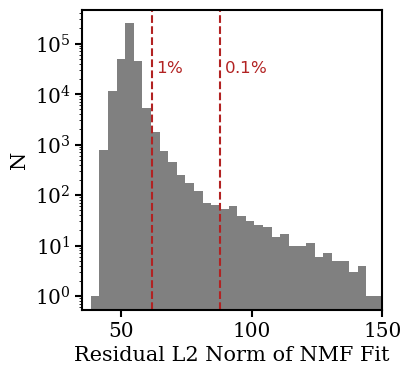

In [247]:
nnmf_resid_plot(nnmf_rnorm)

In [170]:
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# load the MAIN extension directly as an Astropy Table
data_cat = Table.read(filename, hdu="MAIN")
spec_temp_cat = Table.read(filename, hdu="SPECTRA_TEMPLATE")
fspec_cat = Table.read(filename, hdu="FASTSPEC")

keep_mask = spec_temp_cat["SPEC_UMAP_0"] > -50

spec_temp_cat = spec_temp_cat[keep_mask]
data_cat = data_cat[keep_mask]
fspec_cat = fspec_cat[keep_mask]


In [171]:
len(fspec_cat), len(spec_temp_cat)

(368755, 368755)

In [56]:
## get all the targetids in that ball

def inspect_anomalies(spec_cat, umap_x_cen, umap_y_cen, radius_cut = 0.1):
    rads = np.sqrt( (spec_cat["SPEC_UMAP_0"].data - umap_x_cen)**2 + (spec_cat["SPEC_UMAP_1"].data - umap_y_cen)**2 )

    mask = (rads < radius_cut)

    print(f"Objects found = {np.sum(mask)}")
    
    return mask
    
    

In [533]:
##MASK_1 ARE SOME WEIRD SPECTRA DATA ANOMALIES, like poor sky subtraction etc.
mask_1 = inspect_anomalies(spec_temp_cat, 2.8,6, radius_cut = 0.5)

#MASK 2 is also unclear, appear like weird spectra or wrong redrock redshifts 
mask_2 = inspect_anomalies(spec_temp_cat, 5.8,6.7, radius_cut = 0.75)

mask_3 = inspect_anomalies(spec_temp_cat,6.7,7, radius_cut = 0.3)


Objects found = 29
Objects found = 125
Objects found = 547


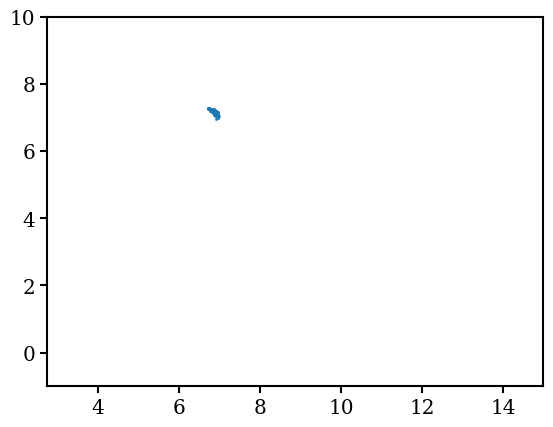

In [534]:
plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_3], spec_temp_cat["SPEC_UMAP_1"][mask_3], s=1)
# plt.text(2.8,6,"1",size=14)
# plt.text(5.8,6.7,"2",size=14)
# plt.text(6.7,7,"3",size=14)
plt.xlim([2.75,15])
plt.ylim([-1,10])
plt.show()

In [535]:
mask_3.shape
spec_mask_3 =  np.median(flux_norm[:,mask_3],axis=1)
spec_mask_2 =  np.median(flux_norm[:,mask_2],axis=1)



In [539]:
# fig, ax = make_subplots(ncol=1, nrow=2, return_fig=True)

# ax[0].plot(wave_rest, spec_mask_3, color="firebrick", lw=1)
# ax[1].plot(wave_rest, spec_mask_2, color="firebrick", lw=1)

# ax[0].set_xlim([3600, 7000])
# ax[1].set_xlim([3600, 7000])

# ax[0].set_xlabel(r"Rest-Frame Wavelength ($\AA$)", fontsize=13)


# # Inset axes: [x0, y0, width, height] in axes fraction
# axins = ax[0].inset_axes([0.25, 0.25, 0.66, 0.66])
# axins.scatter(spec_temp_cat["SPEC_UMAP_0"], spec_temp_cat["SPEC_UMAP_1"], s=0.05,color="k",alpha=0.1,rasterized=True)
# axins.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_3], spec_temp_cat["SPEC_UMAP_1"][mask_3], s=10,color="firebrick",alpha=1,rasterized=True)
# box_size = 3
# axins.set_xlim([6.7-box_size,6.7+box_size])
# axins.set_ylim([7-box_size,7+box_size])
# axins.tick_params(labelsize=10)

# #####


# # axins.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_2], spec_temp_cat["SPEC_UMAP_1"][mask_2], s=5,color="darkorange",alpha=1,rasterized=True)


# plt.show()


In [591]:
data_cat[data_cat["TARGETID"]==39632971707187819]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_SAGA,LOG_MSTAR_M24,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020
,,,,,,,,deg,deg,deg,deg,,Mpc,,,mag,mag,mag,mag,mag,mag,,,,,,,
int64,bytes7,bytes6,int32,float64,float64,bool,float64,float64,float64,float64,float64,bytes22,float32,float32,float32,float32,float32,float32,float32,float32,float32,bytes10,int32,bytes13,bool,float32,float32[2],bool
39632971707187819,main,dark,9746,0.392488152128007,993.3204121589661,False,0.3928395814650998,238.43846876827467,34.52233735896919,238.43846876827467,34.52233735896919,DESI J238.4384+34.5223,2193.069,7.659148,8.094418,23.757221,24.158482,23.322308,23.757221,24.158482,23.322308,ELG,18432,TRACTOR_OG,False,0.0,1.0 .. 0.0,False


In [628]:
data_cat[mask_2 & (data_cat["DWARF_MASKBIT"] == 0)]["RA","DEC"]#,"TARGETID"]

RA,DEC
deg,deg
float64,float64
55.686978648065676,-16.5729108449232
19.370604312824824,-16.280325008389724
67.01672541597753,-13.515708711549108
60.39654497804737,-11.90270477692233
64.60004170329825,-12.000146444868264
349.2509080072483,-10.385015606646144
317.50939727611063,-9.943245164563962
60.90171940514738,-8.07850754681361


In [631]:

from desi_lowz_funcs import save_jpg
import requests

save_jpg_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/jpg_imgs"

def get_rgbs(tgids=[39633447987185055,39636757725057341,39636886834119964,39627984071558664],cutout_arcsec=12):
    '''
    Function that returns the RGB elements
    '''

    cutout_size = cutout_arcsec/0.262

    print(int(cutout_size))
    
    session = requests.Session()

    all_paths = []
    all_zreds = []
    all_radec = []
    
    for tgidi in tgids:
        data_cat_i = data_cat[data_cat["TARGETID"] == tgidi]
        ra_i = data_cat_i["RA"][0]
        dec_i = data_cat_i["DEC"][0]
        img_path_i = f"{save_jpg_path}/img_{tgidi}.jpg" 
        save_jpg(ra_i,dec_i,img_path_i,session, size=int(cutout_size) )
        all_paths.append(img_path_i)
        all_zreds.append(data_cat_i["Z"][0])
        all_radec.append(f"({ra_i:.2f},{dec_i:.2f})")

    return all_paths, all_zreds, all_radec, tgids


In [632]:
paths_mask3, z_mask3, radec_mask3, tgids_mask3 = get_rgbs(tgids=[39633447987185055,39636757725057341,39636886834119964,39627984071558664],cutout_arcsec=10)

38


In [633]:

paths_mask2, z_mask2, radec_mask2, tgids_mask2 = get_rgbs(tgids=[39628023590295406, 39633476617505453, 39627392238491064, 39627462480500683],cutout_arcsec=15)


57


In [614]:
import matplotlib.image as mpimg


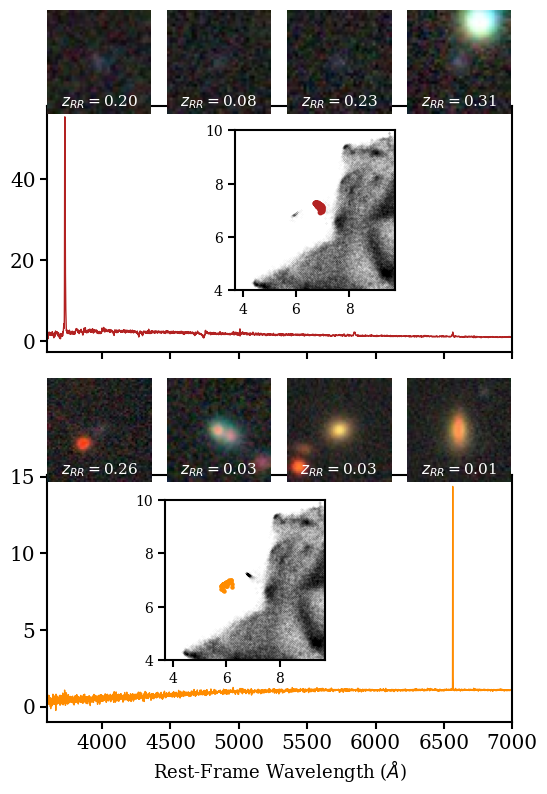

In [637]:

# -----------------------------
# Mock helper: make_subplots
# -----------------------------
def make_subplots_v2(nrow, ncol, return_fig=False):
    fig, axs = plt.subplots(nrow, ncol, figsize=(6, 8),sharex=True)
    plt.subplots_adjust(hspace = .5)
    axs = np.atleast_1d(axs)
    if return_fig:
        return fig, axs
    return axs

# ----------------------------
# Mock data
# -----------------------------
np.random.seed(0)

rgb_imgs_3 = [mpimg.imread(p) for p in paths_mask3]
rgb_imgs_2 = [mpimg.imread(p) for p in paths_mask2]


# -----------------------------
# Main figure
# -----------------------------
fig, ax = make_subplots_v2(nrow=2, ncol=1, return_fig=True)

ax[0].plot(wave_rest, spec_mask_3, color="firebrick", lw=1)
ax[1].plot(wave_rest, spec_mask_2, color="darkorange", lw=1)

ax[0].set_xlim([3600, 7000])
ax[1].set_xlim([3600, 7000])

ax[1].set_xlabel(r"Rest-Frame Wavelength ($\AA$)", fontsize=13)

# -----------------------------
# Inset UMAP scatter
# -----------------------------
axins = ax[0].inset_axes([0.25, 0.25, 0.65, 0.65])

axins.scatter(spec_temp_cat["SPEC_UMAP_0"], spec_temp_cat["SPEC_UMAP_1"], s=0.05,color="k",alpha=0.075,rasterized=True)
axins.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_3], spec_temp_cat["SPEC_UMAP_1"][mask_3], s=10,color="firebrick",alpha=1,rasterized=True)
box_size = 3
axins.set_xlim([6.7-box_size,6.7+box_size])
axins.set_ylim([7-box_size,7+box_size])
axins.tick_params(labelsize=10)
axins.set_aspect("equal", adjustable="box")

# -----------------------------
# Row of 4 RGB images (touching)
# -----------------------------
n_img = 4
img_height = 0.13
img_bottom = 0.87
img_left = 0.111
img_total_width = 0.8
img_width = img_total_width / n_img


for i in range(n_img):
    ax_img = fig.add_axes([
        img_left + i * img_width,
        img_bottom,
        img_width,
        img_height
    ])

    # ax_img.set_title(tgids_mask3[i],fontsize = 8)

    ax_img.imshow(rgb_imgs_3[i], origin="lower")
    ax_img.axis("off")
    ax_img.set_aspect("equal")

    ax_img.text(
        0.5, 0.2, r"$z_{RR}=$" f"{z_mask3[i]:.2f}",
        transform=ax_img.transAxes,
        ha="center", va="top",
        fontsize=11,
        color="white"
    )


#########
########
########
########

axins = ax[1].inset_axes([0.1, 0.25, 0.65, 0.65])

axins.scatter(spec_temp_cat["SPEC_UMAP_0"], spec_temp_cat["SPEC_UMAP_1"], s=0.05,color="k",alpha=0.075,rasterized=True)
axins.scatter(spec_temp_cat["SPEC_UMAP_0"][mask_2], spec_temp_cat["SPEC_UMAP_1"][mask_2], s=5,color="darkorange",alpha=1,rasterized=True)
box_size = 3
axins.set_xlim([6.7-box_size,6.7+box_size])
axins.set_ylim([7-box_size,7+box_size])
axins.tick_params(labelsize=10)
axins.set_aspect("equal", adjustable="box")

# -----------------------------
# Row of 4 RGB images (touching)
# -----------------------------
n_img = 4
img_height = 0.13
img_bottom = 0.41
img_left = 0.111
img_total_width = 0.8
img_width = img_total_width / n_img

labels = [r"$\mathbf{z}_{RR} = 0.1$",r"$\mathbf{z}_{RR} = 0.1$",r"$\mathbf{z}_{RR} = 0.1$",r"$\mathbf{z}_{RR} = 0.1$"] 

for i in range(n_img):
    ax_img = fig.add_axes([
        img_left + i * img_width,
        img_bottom,
        img_width,
        img_height
    ])

    ax_img.imshow(rgb_imgs_2[i], origin="lower")
    ax_img.axis("off")
    ax_img.set_aspect("equal")

    ax_img.text(
        0.5, 0.2, r"$z_{RR}=$" f"{z_mask2[i]:.2f}",
        transform=ax_img.transAxes,
        ha="center", va="top",
        fontsize=11,
        color="white"
    )

plt.savefig("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/plots/umap_anomaly_wrong_zrr.pdf")

plt.show()


In [638]:
flux_norm.shape

(3980, 368755)

In [639]:
len(data_cat)

368755

In [649]:
elg_mask_1 = (data_cat["SAMPLE"] == "ELG") & (data_cat["DWARF_MASKBIT"] == 0) & (data_cat["Z"] > 0) & (data_cat["Z"] < 0.05)
elg_mask_2 = (data_cat["SAMPLE"] == "ELG") & (data_cat["DWARF_MASKBIT"] == 0) & (data_cat["Z"] > 0.05) & (data_cat["Z"] < 0.1)
elg_mask_3 = (data_cat["SAMPLE"] == "ELG") & (data_cat["DWARF_MASKBIT"] == 0) & (data_cat["Z"] > 0.1) & (data_cat["Z"] < 0.15)
elg_mask_4 = (data_cat["SAMPLE"] == "ELG") & (data_cat["DWARF_MASKBIT"] == 0) & (data_cat["Z"] > 0.15) & (data_cat["Z"] < 0.2)
elg_mask_5 = (data_cat["SAMPLE"] == "ELG") & (data_cat["DWARF_MASKBIT"] == 0) & (data_cat["Z"] > 0.2) & (data_cat["Z"] < 0.25)
elg_mask_6 = (data_cat["SAMPLE"] == "ELG") & (data_cat["DWARF_MASKBIT"] == 0) & (data_cat["Z"] > 0.25) & (data_cat["Z"] < 0.3)
elg_mask_7 = (data_cat["SAMPLE"] == "ELG") & (data_cat["DWARF_MASKBIT"] == 0) & (data_cat["Z"] > 0.3) & (data_cat["Z"] < 0.4)



In [641]:
spec_elg_1 =  np.median(flux_norm[:,elg_mask_1],axis=1)
spec_elg_2 =  np.median(flux_norm[:,elg_mask_2],axis=1)
spec_elg_3 =  np.median(flux_norm[:,elg_mask_3],axis=1)
spec_elg_4 =  np.median(flux_norm[:,elg_mask_4],axis=1)
spec_elg_5 =  np.median(flux_norm[:,elg_mask_5],axis=1)




In [650]:
spec_elg_6 =  np.median(flux_norm[:,elg_mask_6],axis=1)
spec_elg_7 =  np.median(flux_norm[:,elg_mask_7],axis=1)

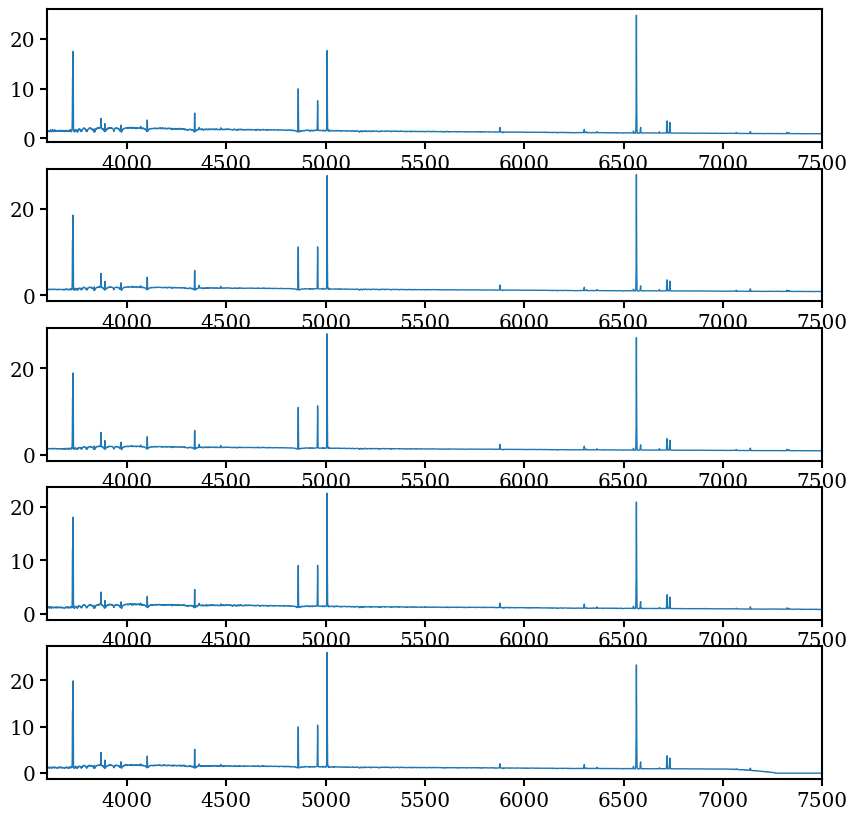

In [651]:
fig,ax = plt.subplots(5,1,figsize = (10,10))
ax[0].plot(wave_rest, spec_elg_1,lw=1)
ax[1].plot(wave_rest, spec_elg_2,lw=1)
ax[2].plot(wave_rest, spec_elg_3,lw=1)
ax[3].plot(wave_rest, spec_elg_6,lw=1)
ax[4].plot(wave_rest, spec_elg_7,lw=1)
for axi in ax:
    axi.set_xlim([3600,7500])
plt.show()


## Given a specific TARGETID, find where it lies in the UMAP space ... useful for VI'ing some sus spectra



In [55]:
# <!-- 39627403265312105 <- lies in weird space
# 39627883991269971 <- not in weird space
# 39627588498359418 <- not in weird space, though same spot as before
# 39627824155330825 <- not in weird space
# 39627624460323510 <- not in weird space ..  -->

In [113]:
def flag_weird_spectra(spec_cat, main_cat, fspec_cat):
    '''
    This is the functiont that constructs the maskbits for spectra that in UMAP space seema bit weird. Those are in the 3 clumps we spot far off
    this will not find all the weird ones, but is a somewhat of a cleaning cut
    '''

    ##MASK_1 ARE SOME WEIRD SPECTRA DATA ANOMALIES, like poor sky subtraction etc.
    mask_1 = inspect_anomalies(spec_temp_cat, 2.8,6, radius_cut = 2)
    
    #MASK 2 is also unclear, appear like weird spectra or wrong redrock redshifts 
    mask_2 = inspect_anomalies(spec_temp_cat, 5.8,6.7, radius_cut = 1)
    
    mask_3 = inspect_anomalies(spec_temp_cat,6.7,7, radius_cut = 0.3)
    ##for the mask_3 we want them to be only ELG objects that we remove!!
    mask_3 = mask_3 & (main_cat["SAMPLE"] == "ELG")

    ## identify objects with confident strong lines
    halpha_snr  = np.array(fspec_cat["HALPHA_FLUX"].data) * np.sqrt(np.array(fspec_cat["HALPHA_FLUX_IVAR"].data))
    hbeta_snr  = np.array(fspec_cat["HBETA_FLUX"]) * np.sqrt(np.array(fspec_cat["HBETA_FLUX_IVAR"]))
    oiii_snr  = np.array(fspec_cat["OIII_5007_FLUX"]) * np.sqrt(np.array(fspec_cat["OIII_5007_FLUX_IVAR"]))
    strong_line_conf = (halpha_snr > 3) & (hbeta_snr > 3) & (oiii_snr > 3)
    
    weird_mask = (mask_1 | mask_2 | mask_3) & (~strong_line_conf)

    print(f"Total weird identified = {np.sum(weird_mask)}")

    #we can check that there are no significant emission lines 

    return weird_mask

In [165]:
spec_temp_cat = Table.read(filename, hdu="SPECTRA_TEMPLATE")
main_cat = Table.read(filename, hdu="MAIN")
fspec_cat = Table.read(filename, hdu="FASTSPEC")


In [115]:
weird_mask = flag_weird_spectra(spec_temp_cat, main_cat, fspec_cat)

Objects found = 29
Objects found = 125
Objects found = 547
Total weird identified = 660


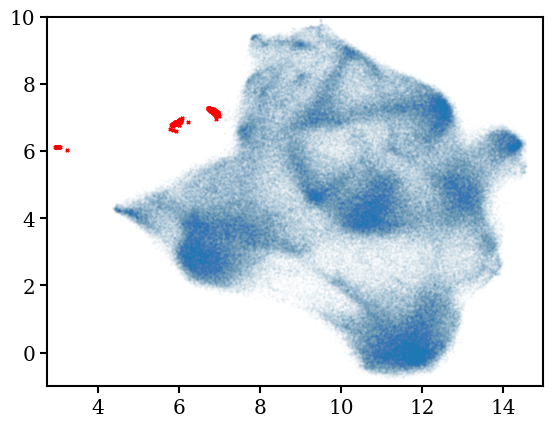

In [116]:
plt.scatter(spec_temp_cat["SPEC_UMAP_0"], spec_temp_cat["SPEC_UMAP_1"], s=0.1,alpha=0.05)

plt.scatter(spec_temp_cat["SPEC_UMAP_0"][weird_mask], spec_temp_cat["SPEC_UMAP_1"][weird_mask], s=5,color="r",marker="x") 

plt.xlim([2.75,15])
plt.ylim([-1,10])
plt.show()

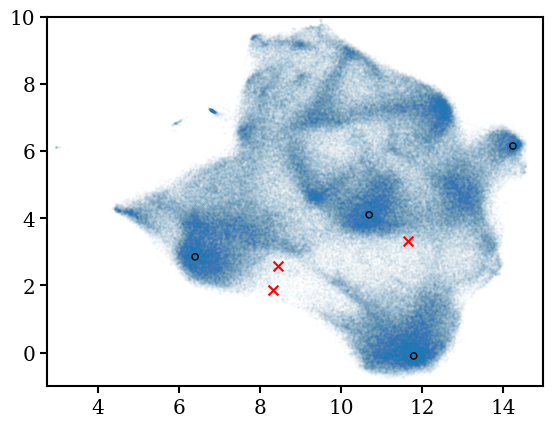

In [153]:
plt.scatter(spec_temp_cat["SPEC_UMAP_0"], spec_temp_cat["SPEC_UMAP_1"], s=0.1,alpha=0.05)


tgids_weird = [39627702956722996, 39627896712597936, 39628414184849968]
for tgidi in tgids_weird:
    mask = (spec_temp_cat["TARGETID"]==tgidi)
    plt.scatter(spec_temp_cat["SPEC_UMAP_0"][mask], spec_temp_cat["SPEC_UMAP_1"][mask], s=50,color="r",marker="x")

plt.scatter(14.25,6.15,s=20,edgecolor="k",facecolor="none")
plt.scatter(11.8,-0.1,s=20,edgecolor="k",facecolor="none")
plt.scatter(6.4,2.85,s=20,edgecolor="k",facecolor="none")
plt.scatter(10.7,4.1,s=20,edgecolor="k",facecolor="none")

plt.xlim([2.75,15])
plt.ylim([-1,10])
plt.show()

In [169]:
## can we make some plots in these clumos??
flux_norm.shape

(3980, 368755)

In [168]:
mask_4.shape

(368807,)

In [172]:
mask_4 = inspect_anomalies(spec_temp_cat, 14.25,6.15, radius_cut = 0.1)
mask_5 = inspect_anomalies(spec_temp_cat, 11.8,-0.1, radius_cut = 0.1)
mask_6 = inspect_anomalies(spec_temp_cat, 6.4,2.85, radius_cut = 0.1)
mask_7 = inspect_anomalies(spec_temp_cat, 10.7,4.1, radius_cut = 0.1)

Objects found = 690
Objects found = 709
Objects found = 534
Objects found = 547


In [174]:
spec_mask_4 =  np.median(flux_norm[:,mask_4],axis=1)
spec_mask_5 =  np.median(flux_norm[:,mask_5],axis=1)
spec_mask_6 =  np.median(flux_norm[:,mask_6],axis=1)
spec_mask_7 =  np.median(flux_norm[:,mask_7],axis=1)



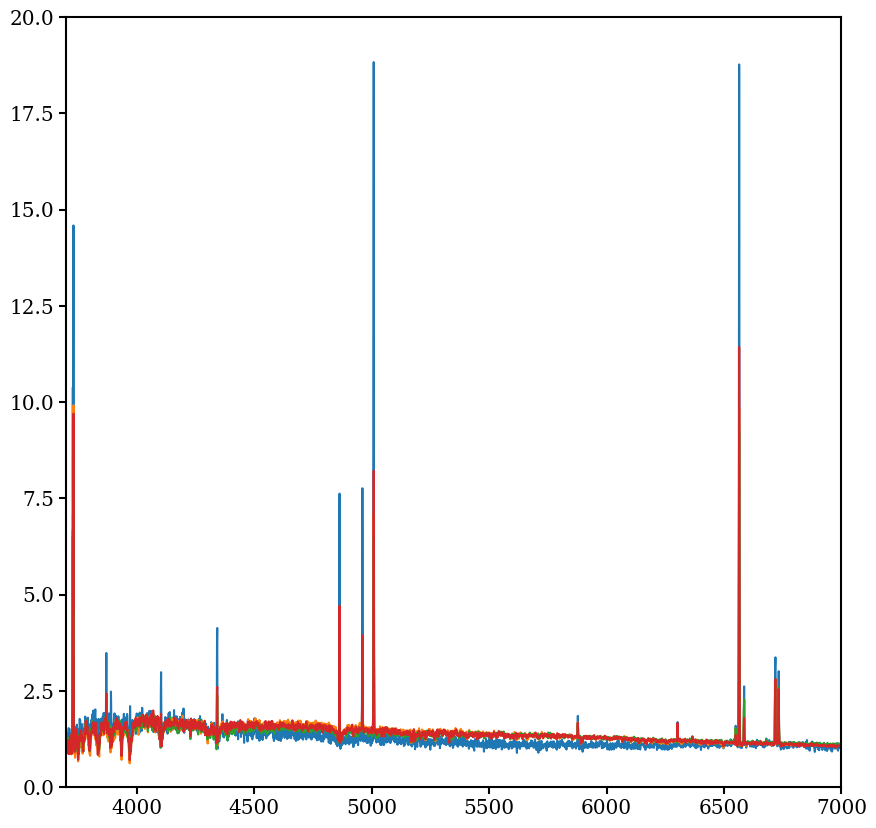

In [192]:
plt.figure(figsize = (10,10))
plt.plot(wave_rest, spec_mask_4)
plt.plot(wave_rest, spec_mask_5)
plt.plot(wave_rest, spec_mask_6)
plt.plot(wave_rest, spec_mask_7)
plt.xlim([3700,7000])
plt.ylim([0,20])
plt.show()

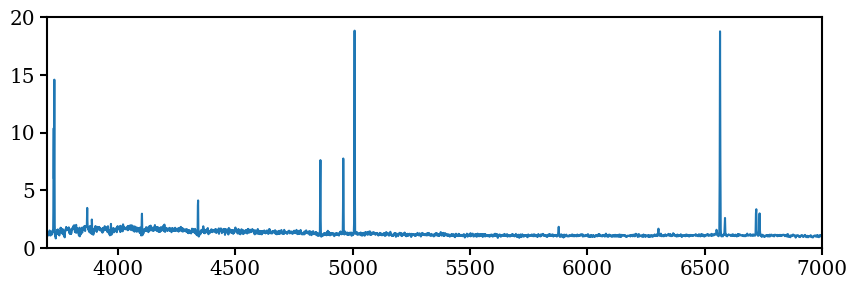

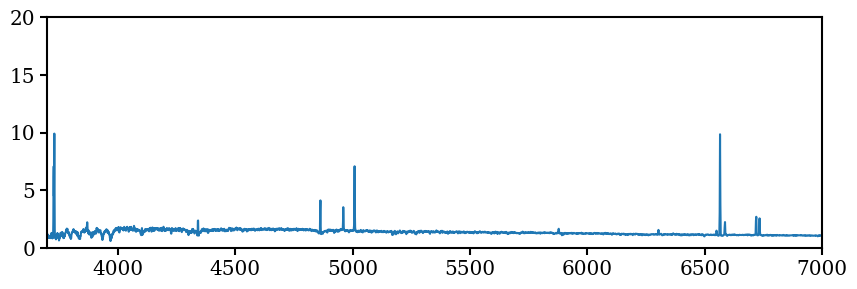

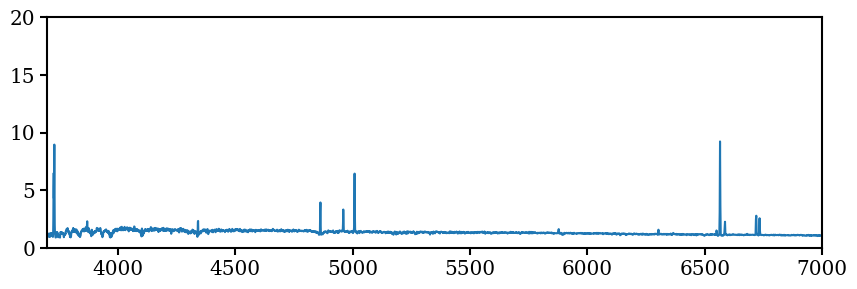

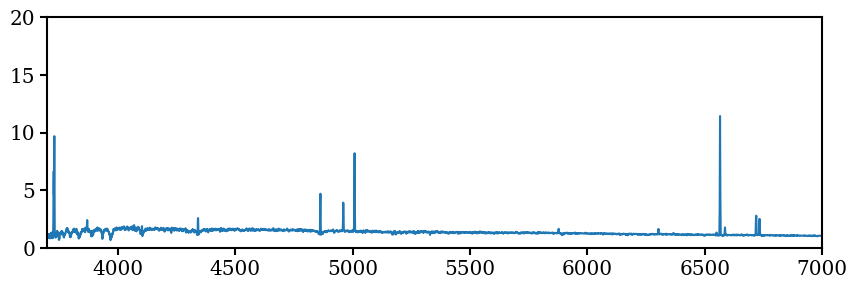

In [184]:
plt.figure(figsize = (10,3))
plt.plot(wave_rest, spec_mask_4)
plt.xlim([3700,7000])
plt.ylim([0,20])
plt.show()

plt.figure(figsize = (10,3))
plt.plot(wave_rest, spec_mask_5)
plt.xlim([3700,7000])
plt.ylim([0,20])
plt.show()

plt.figure(figsize = (10,3))
plt.plot(wave_rest, spec_mask_6)
plt.xlim([3700,7000])
plt.ylim([0,20])
plt.show()

plt.figure(figsize = (10,3))
plt.plot(wave_rest, spec_mask_7)
plt.ylim([0,20])
plt.xlim([3700,7000])
plt.show()